In [2]:
import pandas as pd

# ==========================================================
# Archivo de entrada
# ==========================================================

input_file = r"C:\Users\amigo\Documents\GitHub\PlantingDates\KL and EB data sets\Saxony.xlsx"
output_file = "Disponibilidad_Saxony.xlsx"

# Leer nombres de las hojas
xls = pd.ExcelFile(input_file)

# ==========================================================
# Crear archivo de salida
# ==========================================================

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    for sheet in xls.sheet_names:

        print(f"Procesando {sheet}...")

        df = pd.read_excel(input_file, sheet_name=sheet)

        # Convertir fecha
        df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m%d")

        # Año
        df["Year"] = df["Date"].dt.year

        # Estaciones
        stations = [c for c in df.columns if c not in ["Date", "Year"]]

        # ==================================================
        # Disponibilidad por año
        # ==================================================

        yearly = []

        for year, group in df.groupby("Year"):

            total_days = len(group)

            row = {"Year": year}

            for station in stations:
                row[station] = group[station].count() * 100 / total_days

            yearly.append(row)

        yearly = pd.DataFrame(yearly)

        # ==================================================
        # Disponibilidad total
        # ==================================================

        total_days = len(df)

        total = pd.DataFrame({
            "Station": stations,
            "Availability (%)": [
                df[s].count() * 100 / total_days
                for s in stations
            ]
        })

        total = total.sort_values("Availability (%)", ascending=False)

        # ==================================================
        # Guardar
        # ==================================================

        yearly.to_excel(
            writer,
            sheet_name=f"{sheet}_Yearly",
            index=False
        )

        total.to_excel(
            writer,
            sheet_name=f"{sheet}_Total",
            index=False
        )

print("Proceso terminado.")
print(f"Archivo generado: {output_file}")

Procesando Completeness...


IndexError: At least one sheet must be visible

In [3]:
import pandas as pd

# ==========================================================
# CONFIGURACIÓN
# ==========================================================

input_file = r"C:\Users\amigo\Documents\GitHub\PlantingDates\KL and EB data sets\Saxony.xlsx"
output_file = r"C:\Users\amigo\Documents\GitHub\PlantingDates\KL and EB data sets\Disponibilidad_Saxony.xlsx"

# ==========================================================
# LEER ARCHIVO
# ==========================================================

xls = pd.ExcelFile(input_file)

print("Hojas encontradas:")
print(xls.sheet_names)

# Se ignora la primera hoja (coordenadas o metadatos)
data_sheets = xls.sheet_names[1:]

# ==========================================================
# CREAR ARCHIVO DE SALIDA
# ==========================================================

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    for sheet in data_sheets:

        print(f"Procesando {sheet}...")

        # Leer hoja
        df = pd.read_excel(input_file, sheet_name=sheet)

        # Verificar que exista la columna Date
        if "Date" not in df.columns:
            print(f"   Se omitió '{sheet}' porque no contiene la columna 'Date'.")
            continue

        # Obtener año (las fechas tienen formato 19940101)
        df["Year"] = df["Date"].astype(str).str[:4].astype(int)

        # Columnas de estaciones
        stations = [c for c in df.columns if c not in ["Date", "Year"]]

        # ======================================================
        # DISPONIBILIDAD POR AÑO
        # ======================================================

        yearly_results = []

        for year, group in df.groupby("Year"):

            total_days = len(group)

            row = {"Year": year}

            for station in stations:
                available = group[station].count()
                row[station] = available * 100 / total_days

            yearly_results.append(row)

        yearly = pd.DataFrame(yearly_results)

        # ======================================================
        # DISPONIBILIDAD TOTAL
        # ======================================================

        total_days = len(df)

        total = pd.DataFrame({
            "Station": stations,
            "Availability (%)": [
                df[s].count() * 100 / total_days
                for s in stations
            ]
        })

        total = total.sort_values(
            by="Availability (%)",
            ascending=False
        ).reset_index(drop=True)

        # ======================================================
        # GUARDAR
        # ======================================================

        yearly.to_excel(
            writer,
            sheet_name=f"{sheet}_Yearly",
            index=False
        )

        total.to_excel(
            writer,
            sheet_name=f"{sheet}_Total",
            index=False
        )

print("\nProceso terminado correctamente.")
print(f"Archivo generado:\n{output_file}")

Hojas encontradas:
['Completeness', 'TMK', 'TXK', 'TNK', 'TGK', 'RSK', 'UPM', 'SDK', 'V_TE002M', 'V_TE005M', 'V_TE010M', 'V_TE020M', 'V_TE050M']
Procesando TMK...
Procesando TXK...
Procesando TNK...
Procesando TGK...
Procesando RSK...
Procesando UPM...
Procesando SDK...
Procesando V_TE002M...
Procesando V_TE005M...
Procesando V_TE010M...
Procesando V_TE020M...
Procesando V_TE050M...

Proceso terminado correctamente.
Archivo generado:
C:\Users\amigo\Documents\GitHub\PlantingDates\KL and EB data sets\Disponibilidad_Saxony.xlsx


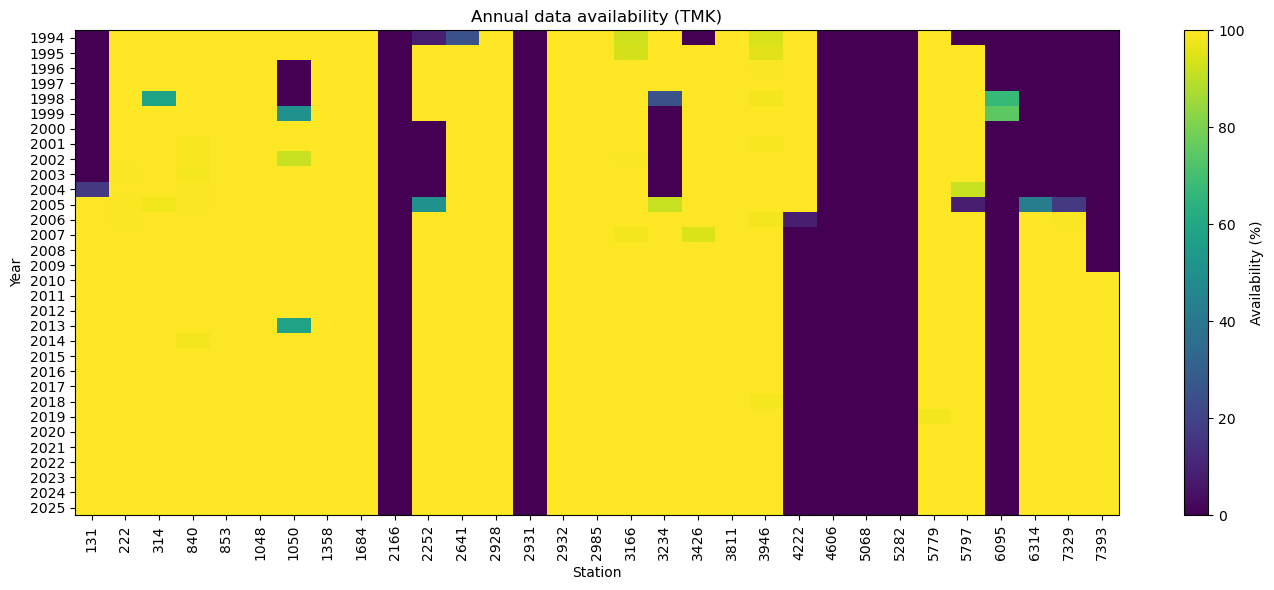

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Leer datos
# ==============================

file = r"C:\Users\amigo\Documents\GitHub\PlantingDates\KL and EB data sets\Saxony.xlsx"

df = pd.read_excel(file, sheet_name="TMK")

df["Year"] = df["Date"].astype(str).str[:4].astype(int)

stations = [c for c in df.columns if c not in ["Date", "Year"]]

# ==============================
# Disponibilidad anual
# ==============================

availability = []

for year, group in df.groupby("Year"):

    row = []

    for station in stations:
        row.append(group[station].count()*100/len(group))

    availability.append(row)

availability = pd.DataFrame(
    availability,
    index=sorted(df["Year"].unique()),
    columns=stations
)

# ==============================
# Figura
# ==============================

plt.figure(figsize=(14,6))

plt.imshow(
    availability,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=100
)

plt.colorbar(label="Availability (%)")

plt.xticks(range(len(stations)), stations, rotation=90)
plt.yticks(range(len(availability.index)), availability.index)

plt.xlabel("Station")
plt.ylabel("Year")

plt.title("Annual data availability (TMK)")

plt.tight_layout()
plt.show()

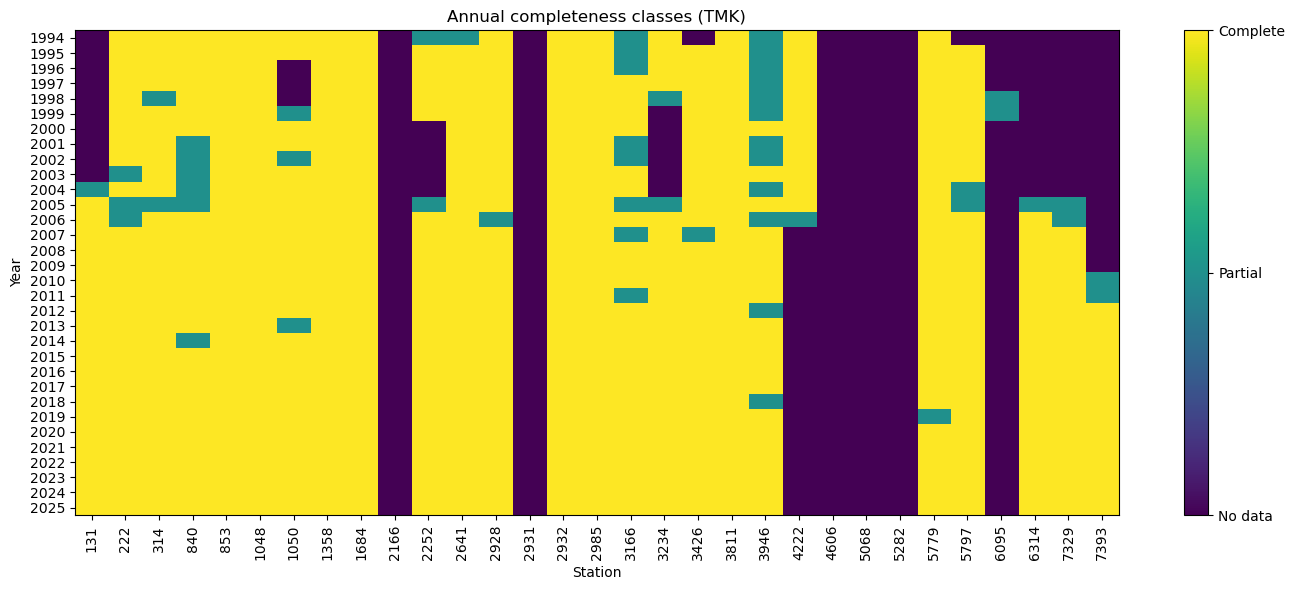

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

file = r"C:\Users\amigo\Documents\GitHub\PlantingDates\KL and EB data sets\Saxony.xlsx"

df = pd.read_excel(file, sheet_name="TMK")

df["Year"] = df["Date"].astype(str).str[:4].astype(int)

stations = [c for c in df.columns if c not in ["Date","Year"]]

binary = []

for year, group in df.groupby("Year"):

    row = []

    for station in stations:

        if group[station].count()==0:
            row.append(0)

        elif group[station].count()==len(group):
            row.append(2)

        else:
            row.append(1)

    binary.append(row)

binary = pd.DataFrame(
    binary,
    index=sorted(df["Year"].unique()),
    columns=stations
)

plt.figure(figsize=(14,6))

plt.imshow(
    binary,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=2
)

cbar = plt.colorbar()
cbar.set_ticks([0,1,2])
cbar.set_ticklabels(["No data","Partial","Complete"])

plt.xticks(range(len(stations)), stations, rotation=90)
plt.yticks(range(len(binary.index)), binary.index)

plt.xlabel("Station")
plt.ylabel("Year")

plt.title("Annual completeness classes (TMK)")

plt.tight_layout()
plt.show()

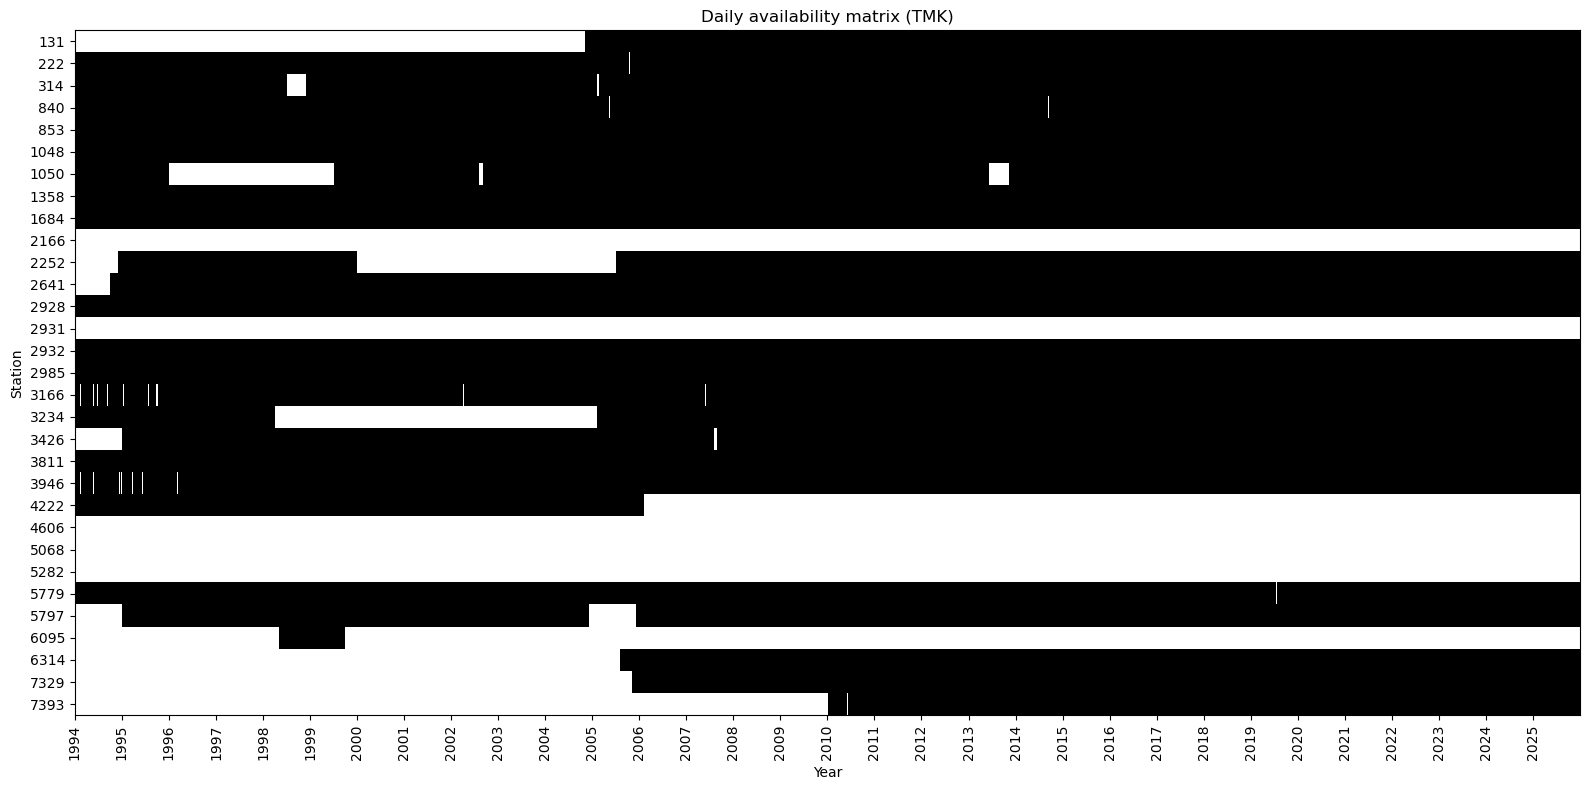

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

file = r"C:\Users\amigo\Documents\GitHub\PlantingDates\KL and EB data sets\Saxony.xlsx"

df = pd.read_excel(file, sheet_name="TMK")

stations = [c for c in df.columns if c!="Date"]

# 1 = dato disponible
# 0 = dato faltante

presence = df[stations].notna().astype(int)

plt.figure(figsize=(16,8))

plt.imshow(
    presence.T,
    aspect="auto",
    interpolation="nearest",
    cmap="Greys"
)

years = pd.to_datetime(
    df["Date"].astype(str),
    format="%Y%m%d"
).dt.year

tick_positions = []
tick_labels = []

for y in sorted(years.unique()):
    idx = years[years==y].index[0]
    tick_positions.append(idx)
    tick_labels.append(str(y))

plt.xticks(
    tick_positions,
    tick_labels,
    rotation=90
)

plt.yticks(range(len(stations)), stations)

plt.xlabel("Year")
plt.ylabel("Station")

plt.title("Daily availability matrix (TMK)")

plt.tight_layout()
plt.show()

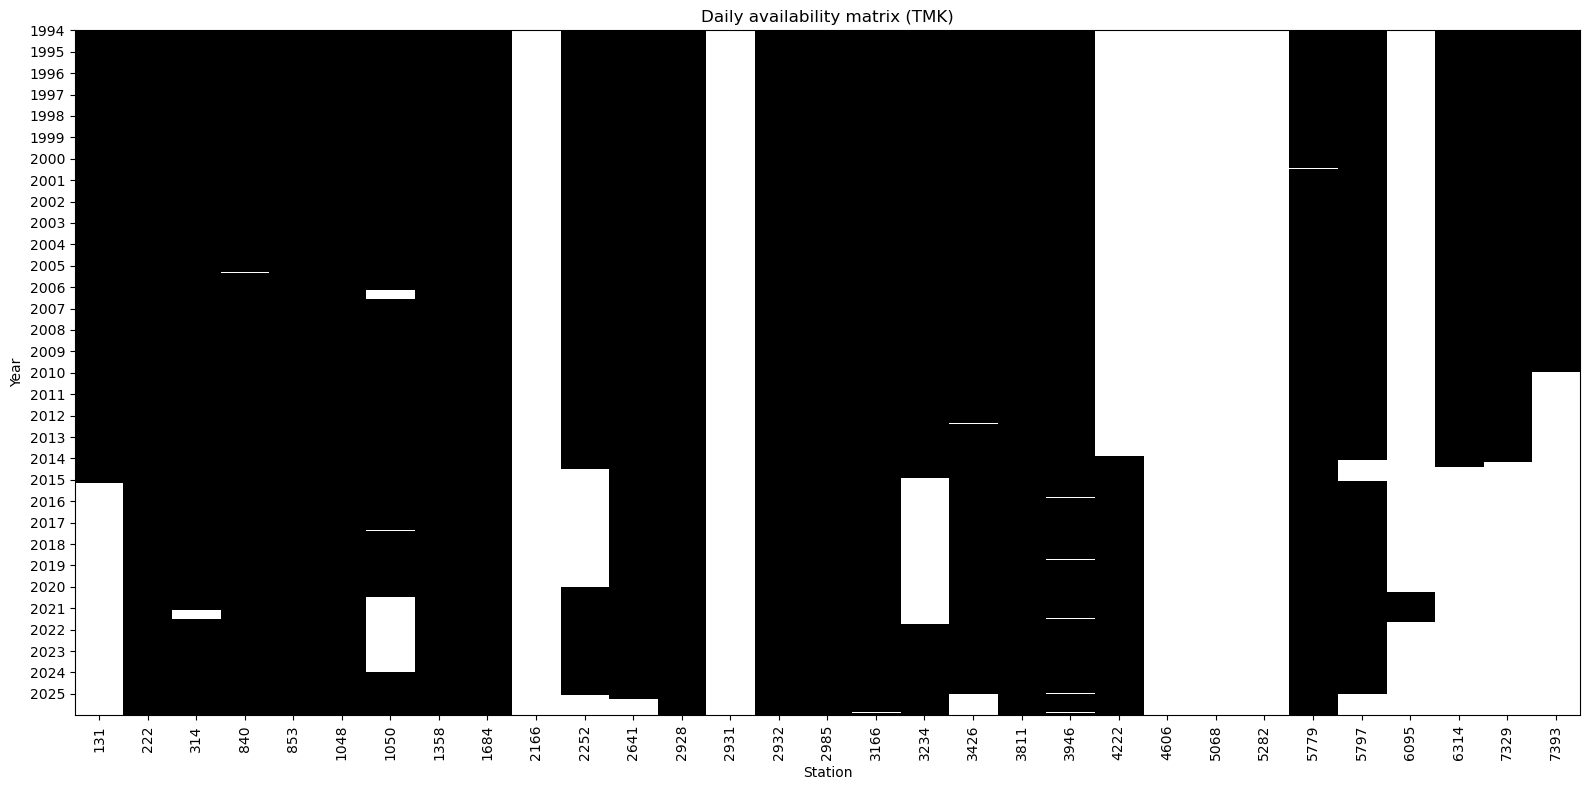

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

file = r"C:\Users\amigo\Documents\GitHub\PlantingDates\KL and EB data sets\Saxony.xlsx"

df = pd.read_excel(file, sheet_name="TMK")

stations = [c for c in df.columns if c != "Date"]

# 1 = dato disponible
# 0 = dato faltante
presence = df[stations].notna().astype(int)

plt.figure(figsize=(16, 8))

presence = presence.iloc[::-1]

plt.imshow(
    presence,
    aspect="auto",
    interpolation="nearest",
    cmap="Greys"
)

# Obtener los años
years = pd.to_datetime(
    df["Date"].astype(str),
    format="%Y%m%d"
).dt.year

tick_positions = []
tick_labels = []

for y in sorted(years.unique()):
    idx = years[years == y].index[0]
    tick_positions.append(idx)
    tick_labels.append(str(y))

# Estaciones en X
plt.xticks(
    range(len(stations)),
    stations,
    rotation=90
)

# Años en Y
plt.yticks(
    tick_positions,
    tick_labels
)

plt.xlabel("Station")
plt.ylabel("Year")

plt.title("Daily availability matrix (TMK)")

plt.tight_layout()
plt.show()

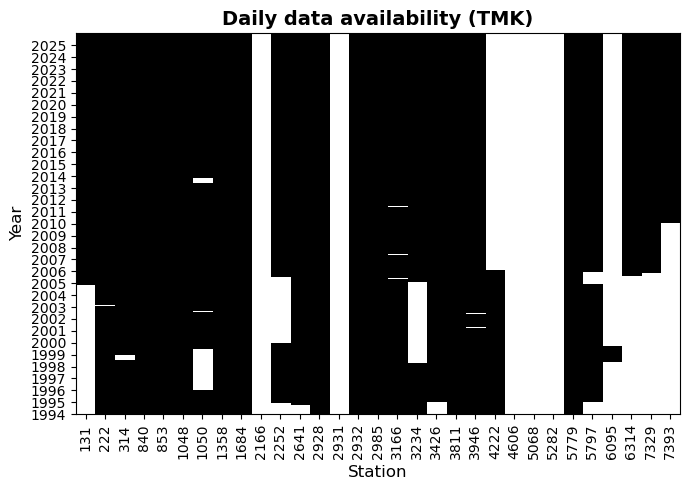

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Archivo
# ==========================================================

file = r"C:\Users\amigo\Documents\GitHub\PlantingDates\KL and EB data sets\Saxony.xlsx"

# ==========================================================
# Leer datos
# ==========================================================

df = pd.read_excel(file, sheet_name="TMK")

stations = [c for c in df.columns if c != "Date"]

# Convertir fechas
dates = pd.to_datetime(df["Date"].astype(str), format="%Y%m%d")
years = dates.dt.year

# ==========================================================
# Matriz de disponibilidad
# ==========================================================

# 1 = dato disponible
# 0 = dato faltante
presence = df[stations].notna().astype(int)

# Invertir el orden de las filas (2025 arriba)
presence = presence.iloc[::-1].reset_index(drop=True)
years = years.iloc[::-1].reset_index(drop=True)

# ==========================================================
# Figura
# ==========================================================

plt.figure(figsize=(7, 5))

plt.imshow(
    presence,
    aspect="auto",
    interpolation="nearest",
    cmap="Greys",
    vmin=0,
    vmax=1
)

# ==========================================================
# Eje Y (años)
# ==========================================================

tick_positions = []
tick_labels = []

for year in sorted(years.unique(), reverse=True):
    pos = years[years == year].index[-1]
    tick_positions.append(pos)
    tick_labels.append(str(year))

plt.yticks(tick_positions, tick_labels)

# ==========================================================
# Eje X (estaciones)
# ==========================================================

plt.xticks(
    range(len(stations)),
    stations,
    rotation=90
)

# ==========================================================
# Etiquetas
# ==========================================================

plt.xlabel("Station", fontsize=12)
plt.ylabel("Year", fontsize=12)

plt.title(
    "Daily data availability (TMK)",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
plt.show()

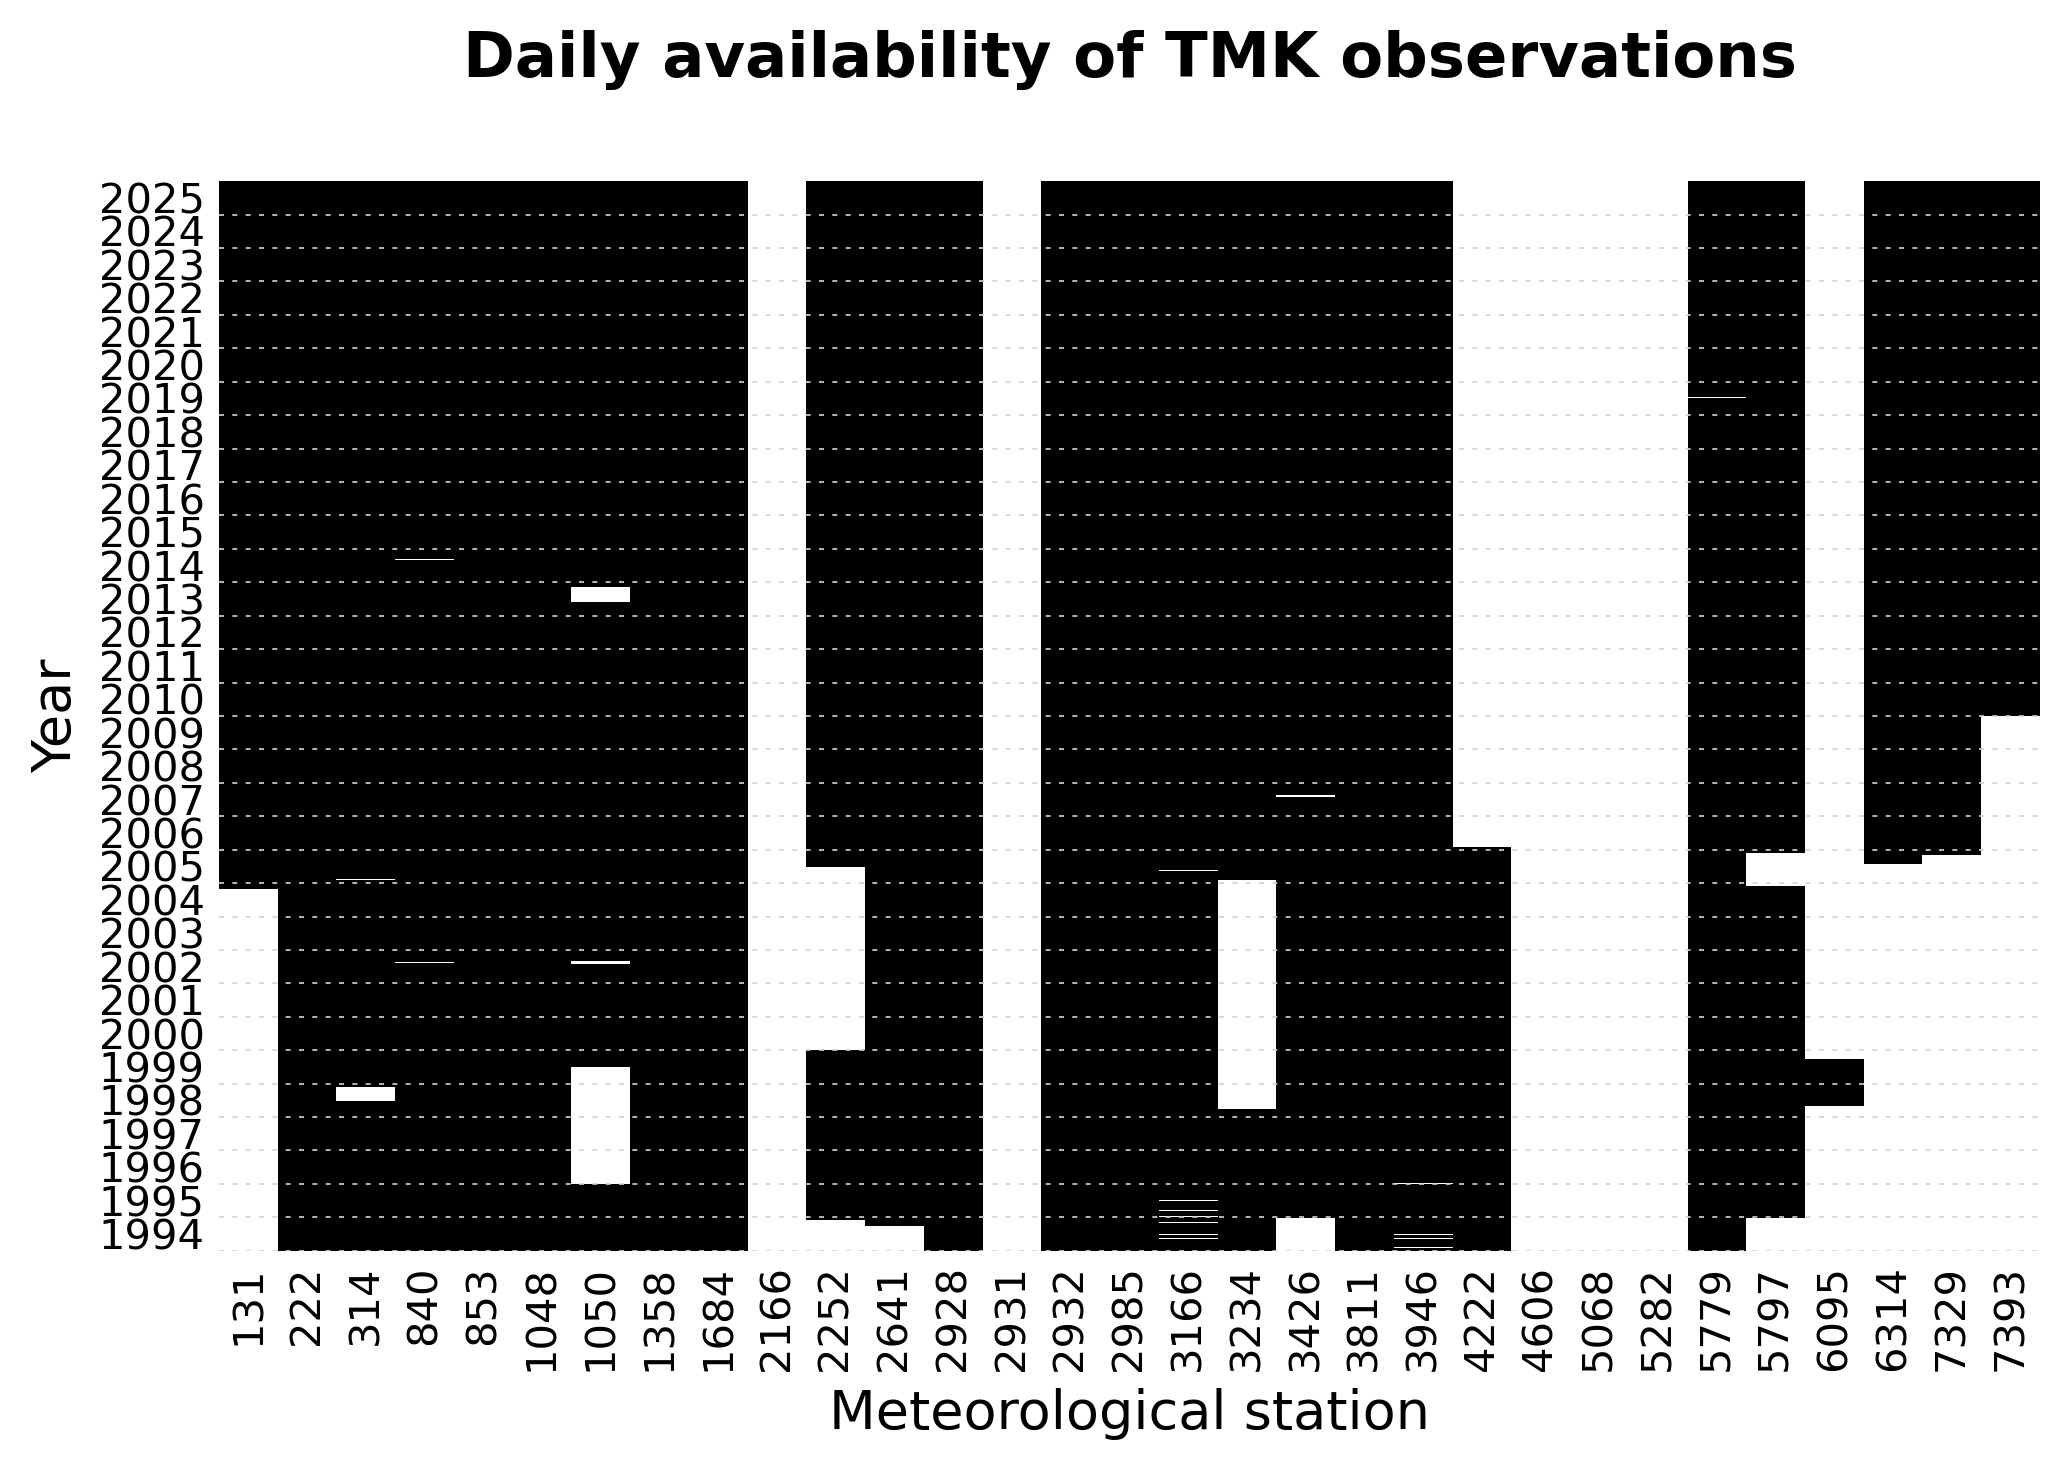

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# CONFIGURACIÓN
# ==========================================================

file = r"C:\Users\amigo\Documents\GitHub\PlantingDates\KL and EB data sets\Saxony.xlsx"

variable = "TMK"

# ==========================================================
# LEER DATOS
# ==========================================================

df = pd.read_excel(file, sheet_name=variable)

dates = pd.to_datetime(df["Date"].astype(str), format="%Y%m%d")

years = dates.dt.year

stations = [c for c in df.columns if c != "Date"]

# ==========================================================
# MATRIZ DE DISPONIBILIDAD
# ==========================================================

presence = df[stations].notna().astype(int)

# 2025 arriba
presence = presence.iloc[::-1].reset_index(drop=True)
years = years.iloc[::-1].reset_index(drop=True)

# ==========================================================
# FIGURA
# ==========================================================

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

im = ax.imshow(
    presence,
    cmap="Greys",
    interpolation="nearest",
    aspect="auto",
    vmin=0,
    vmax=1
)

# ==========================================================
# ETIQUETAS DEL EJE X
# ==========================================================

ax.set_xticks(range(len(stations)))
ax.set_xticklabels(stations, rotation=90)

# Colocar las estaciones arriba
ax.xaxis.tick_bottom()
ax.xaxis.set_label_position('bottom')

# ==========================================================
# ETIQUETAS DEL EJE Y
# ==========================================================

tick_positions = []
tick_labels = []

unique_years = sorted(years.unique(), reverse=True)

for year in unique_years:

    idx = years[years == year].index

    center = (idx.min() + idx.max()) / 2

    tick_positions.append(center)
    tick_labels.append(str(year))

    # Línea divisoria entre años
    line = ax.axhline(idx.max() + 0.5,
               color="lightgray",
               linewidth=0.4)
    
    line.set_dashes((3, 5))  # 3 pt de línea, 3 pt de espacio

ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

# ==========================================================
# ESTILO
# ==========================================================

ax.set_xlabel("Meteorological station", fontsize=13)
ax.set_ylabel("Year", fontsize=13)

ax.set_title(
    "Daily availability of TMK observations",
    fontsize=15,
    fontweight="bold",
    pad=25
)

# Eliminar marco
for spine in ax.spines.values():
    spine.set_visible(False)

# Marcas pequeñas
ax.tick_params(length=0)

plt.tight_layout()

# ==========================================================
# GUARDAR
# ==========================================================

#plt.savefig(
#    "TMK_daily_availability.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()